<a href="https://colab.research.google.com/github/dhanushkumar-amk/PYTHON-AI-ML-INTERNSHIP/blob/main/Time_Series_Forecasting_with_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Installtion**

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.3 MB/s eta 0:00:00


### **Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

### **Load Dataset**

In [3]:
df = pd.read_csv("PJME_hourly.csv")

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


### **Dataset Information**

In [4]:
print("Shape:", df.shape)

df.info()

Shape: (145366, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


### **Missing Values**

In [5]:
df.isnull().sum()

,0
Datetime,0
PJME_MW,0


### **Convert Datetime**

In [6]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.set_index("Datetime")

df = df.sort_index()

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## **Plot Energy Consumption**

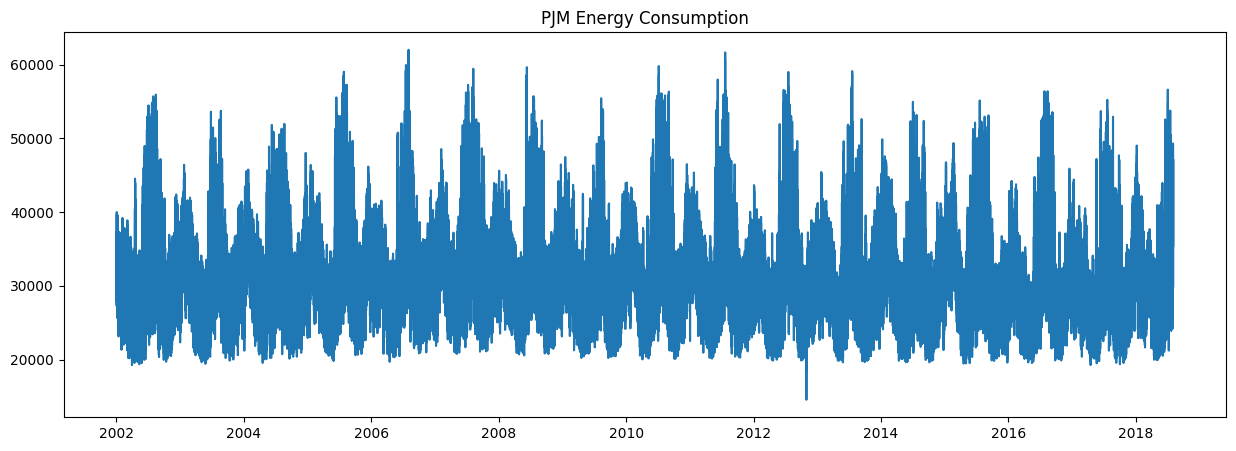

In [7]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["PJME_MW"]
)

plt.title(
    "PJM Energy Consumption"
)

plt.show()


## **Markdown Cell**

**Observation:**

- Energy consumption varies significantly over time.
- Seasonal patterns can be observed.
- Multiple peaks and troughs indicate demand fluctuations

## **Train-Test Split**

In [8]:
train = df.loc[
    df.index < "2015-01-01"
]

test = df.loc[
    df.index >= "2015-01-01"
]

print(train.shape)

print(test.shape)

(113926, 1)
(31440, 1)


## **Visualize Train/Test**

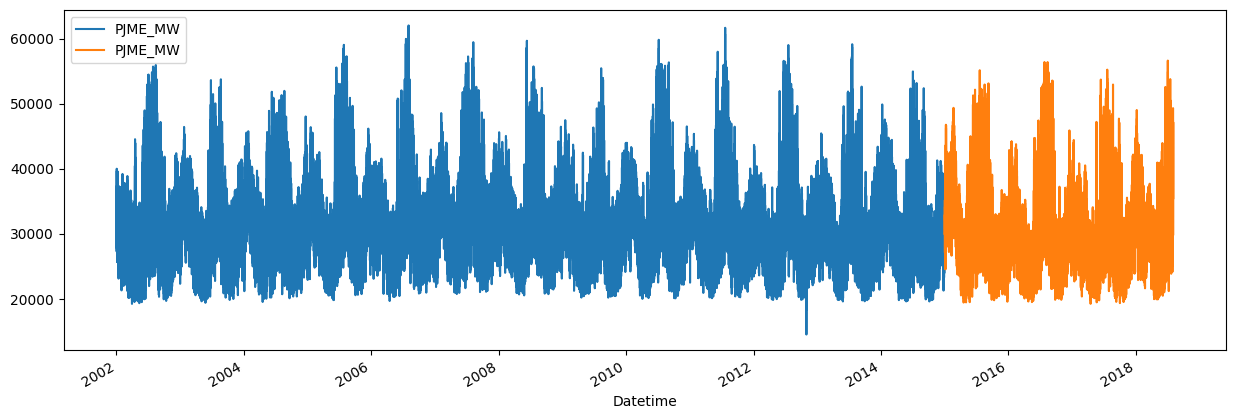

In [9]:
fig, ax = plt.subplots(
    figsize=(15,5)
)

train.plot(
    ax=ax,
    label="Train"
)

test.plot(
    ax=ax,
    label="Test"
)

plt.legend()

plt.show()

## **Feature Engineering Function**

In [10]:
def create_features(df):

    df = df.copy()

    df["hour"] = df.index.hour

    df["dayofweek"] = (
        df.index.dayofweek
    )

    df["quarter"] = (
        df.index.quarter
    )

    df["month"] = (
        df.index.month
    )

    df["year"] = (
        df.index.year
    )

    df["dayofyear"] = (
        df.index.dayofyear
    )

    return df

## **Apply Features**

In [11]:
train = create_features(train)

test = create_features(test)

train.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1


## **Select Features**

In [12]:
FEATURES = [
    "hour",
    "dayofweek",
    "quarter",
    "month",
    "year",
    "dayofyear"
]

TARGET = "PJME_MW"

X_train = train[FEATURES]

y_train = train[TARGET]

X_test = test[FEATURES]

y_test = test[TARGET]

## **Train XGBoost**

In [13]:
reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    objective="reg:squarederror"
)

reg.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## **Predict**

In [14]:
test["prediction"] = (
    reg.predict(X_test)
)

test.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,prediction
Datetime,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,32144.500000
2015-01-01 01:00:00,31647.0,1,3,1,1,2015,1,30764.453125
2015-01-01 02:00:00,30755.0,2,3,1,1,2015,1,30539.300781
2015-01-01 03:00:00,30189.0,3,3,1,1,2015,1,30227.699219
2015-01-01 04:00:00,29890.0,4,3,1,1,2015,1,30219.828125


## **Plot Predictions**

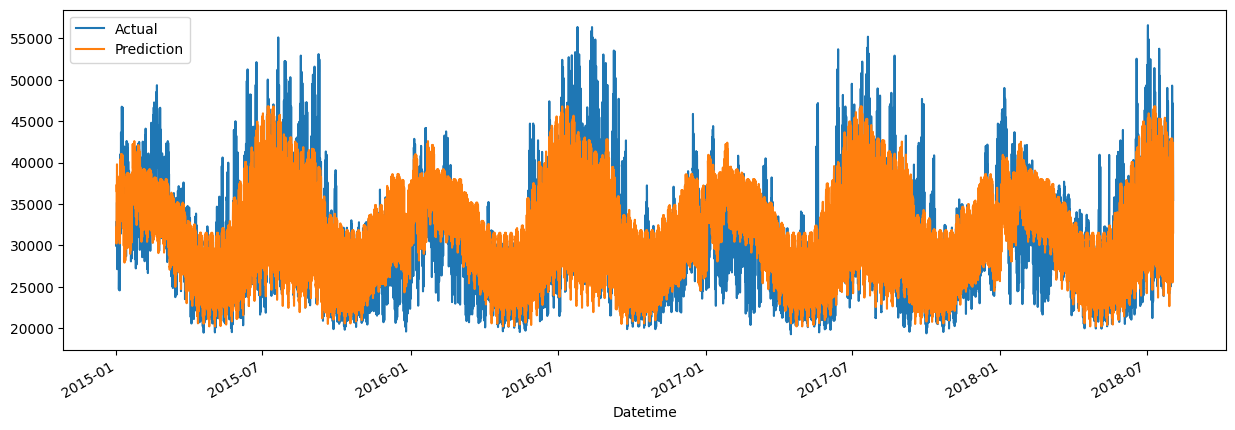

In [15]:
ax = test[
    ["PJME_MW"]
].plot(
    figsize=(15,5)
)

test["prediction"].plot(
    ax=ax
)

plt.legend(
    ["Actual",
     "Prediction"]
)

plt.show()

## **Evaluate Model**

In [16]:
mae = mean_absolute_error(
    y_test,
    test["prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test["prediction"]
    )
)

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 2932.3901425582458
RMSE: 3868.1756514143044


## **Feature Importance**

In [17]:
feature_importance = pd.DataFrame(
    {
        "Feature": FEATURES,
        "Importance":
        reg.feature_importances_
    }
)

feature_importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,hour,0.387463
3,month,0.310397
1,dayofweek,0.113365
5,dayofyear,0.112359
2,quarter,0.052879
4,year,0.023538


## **Plot Feature Importance**

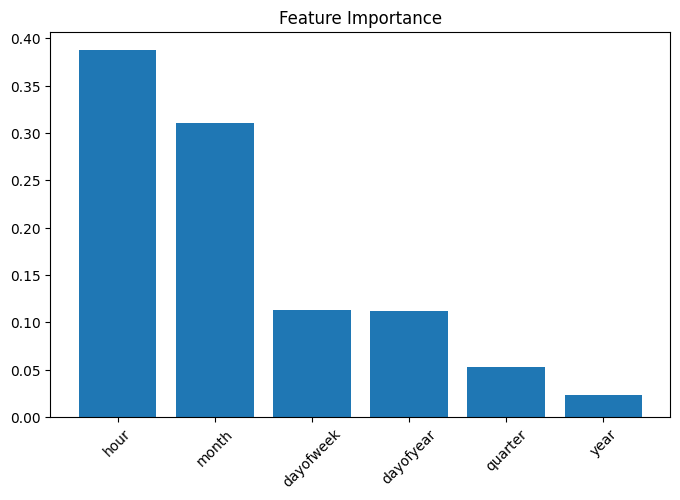

In [18]:
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.title(
    "Feature Importance"
)

plt.show()

## **Save Predictions**

In [19]:
test.to_csv(
    "predictions.csv"
)

print(
    "Predictions saved successfully"
)

Predictions saved successfully


Conclusion

1. The PJM energy dataset was successfully analyzed.
2. Feature engineering was performed using time-based features.
3. An XGBoost regression model was trained for forecasting.
4. Predictions closely followed actual energy demand patterns.
5. Model performance was evaluated using MAE and RMSE metrics.
6. Hour, month, and day-of-year were among the most important features.